# **Detecting Healthcare Provider Fraud Using Aggregated Claims Analysis and Machine Learning**

# **Loading Relevent Files and Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
train_target = pd.read_csv('Train.csv')
train_ben = pd.read_csv('Train_Beneficiarydata.csv')
train_inpatient = pd.read_csv('Train_Inpatientdata.csv')
train_outpatient = pd.read_csv('Train_Outpatientdata.csv', engine='python')

# Combine Inpatient and Outpatient for a holistic view of claims
train_inpatient['Type'] = 'Inpatient'
train_outpatient['Type'] = 'Outpatient'
all_claims = pd.concat([train_inpatient, train_outpatient], axis=0, sort=False)

# Merge claims with the fraud labels
full_data = pd.merge(all_claims, train_target, on='Provider', how='left')

#**Exploratory Data Analysis**

## **Dataset Description**


In [ ]:
full_data.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,Type,PotentialFraud
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inpatient,Yes
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,Inpatient,No
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inpatient,No
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,Inpatient,No
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,Inpatient,No


In [ ]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558211 entries, 0 to 558210
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   BeneID                  558211 non-null  object 
 1   ClaimID                 558211 non-null  object 
 2   ClaimStartDt            558211 non-null  object 
 3   ClaimEndDt              558211 non-null  object 
 4   Provider                558211 non-null  object 
 5   InscClaimAmtReimbursed  558211 non-null  int64  
 6   AttendingPhysician      556703 non-null  object 
 7   OperatingPhysician      114447 non-null  object 
 8   OtherPhysician          199736 non-null  object 
 9   AdmissionDt             40474 non-null   object 
 10  ClmAdmitDiagnosisCode   145899 non-null  object 
 11  DeductibleAmtPaid       557312 non-null  float64
 12  DischargeDt             40474 non-null   object 
 13  DiagnosisGroupCode      40474 non-null   object 
 14  ClmDiagnosisCode_1  

## **Checking and Handling Missing Values**
In this missing values are identified and handeled with imputation

--- Missing Values in Target Labels ---


,Total,Percentage




--- Missing Values in Beneficiary Data ---


,Total,Percentage
DOD,137135,98.974422




--- Missing Values in Inpatient Claims ---


,Total,Percentage
ClmProcedureCode_6,40474,100.000000
ClmProcedureCode_5,40465,99.977764
ClmProcedureCode_4,40358,99.713396
ClmProcedureCode_3,39509,97.615753
ClmDiagnosisCode_10,36547,90.297475
OtherPhysician,35784,88.412314
ClmProcedureCode_2,35020,86.524683
ClmProcedureCode_1,17326,42.807728
OperatingPhysician,16644,41.122696
ClmDiagnosisCode_9,13497,33.347334




--- Missing Values in Outpatient Claims ---


,Total,Percentage
ClmProcedureCode_6,517737,100.000000
ClmProcedureCode_5,517737,100.000000
ClmProcedureCode_4,517735,99.999614
ClmProcedureCode_3,517733,99.999227
ClmProcedureCode_2,517701,99.993047
ClmProcedureCode_1,517575,99.968710
ClmDiagnosisCode_10,516654,99.790820
ClmDiagnosisCode_9,502899,97.134066
ClmDiagnosisCode_8,494825,95.574587
ClmDiagnosisCode_7,484776,93.633640


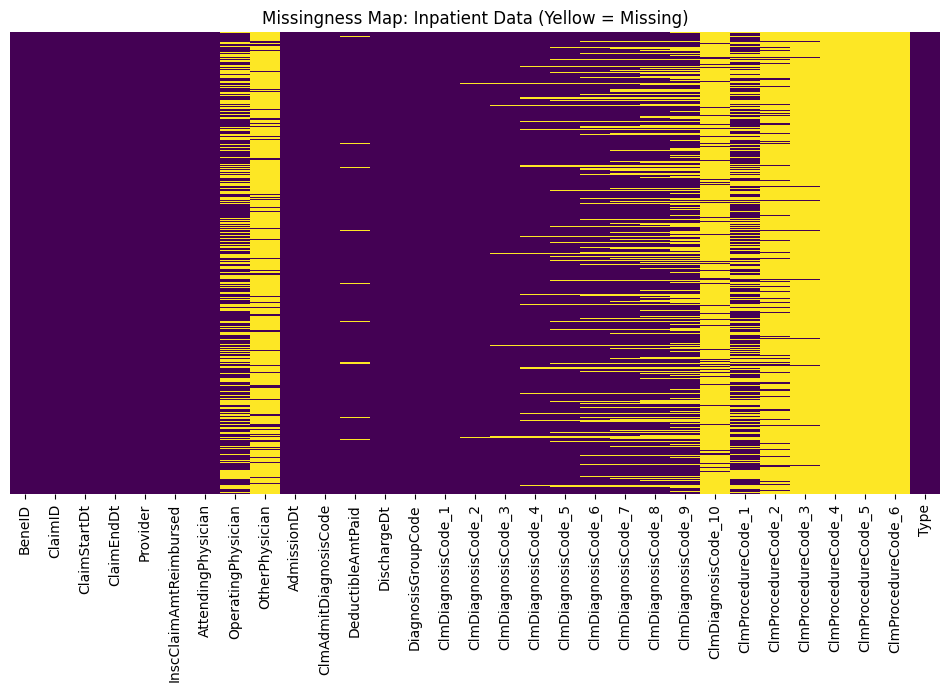

In [ ]:
def missing_data_check(df, name):
    print(f"--- Missing Values in {name} ---")
    null_counts = df.isnull().sum()
    null_percent = (df.isnull().sum() / len(df)) * 100

    missing_df = pd.concat([null_counts, null_percent], axis=1, keys=['Total', 'Percentage'])
    # Only show columns that actually have missing values
    display(missing_df[missing_df['Total'] > 0].sort_values(by='Total', ascending=False))
    print("\n")

# 1. Check for missing values in each file
missing_data_check(train_target, "Target Labels")
missing_data_check(train_ben, "Beneficiary Data")
missing_data_check(train_inpatient, "Inpatient Claims")
missing_data_check(train_outpatient, "Outpatient Claims")

# 2. Visualizing Missing Data Patterns (Inpatient example)
# This helps identify if certain columns (like Procedure Codes) are missing together
plt.figure(figsize=(12, 6))
sns.heatmap(train_inpatient.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missingness Map: Inpatient Data (Yellow = Missing)')
plt.show()

In [ ]:
# 1. Handling Beneficiary Data (Demographics & Chronic Conditions)
# DOD (Date of Death) is naturally empty for living patients.
# We create a binary 'IsDeceased' flag and then drop/ignore the date for modeling.
train_ben['IsDeceased'] = train_ben['DOD'].notnull().astype(int)

# 2. Handling Financial Nulls
# Financial columns should never be null. Fill with 0 to ensure aggregations work.
financial_cols = ['InscClaimAmtReimbursed', 'DeductibleAmtPaid']
train_inpatient[financial_cols] = train_inpatient[financial_cols].fillna(0)
train_outpatient[financial_cols] = train_outpatient[financial_cols].fillna(0)

# 3. Handling Categorical Sparse Data (Diagnosis & Procedure Codes)
# In this dataset, 'NA' in DiagnosisCode_10 just means the patient didn't have 10 conditions.
# We fill these with a specific 'None' string so they can be encoded later.
diag_cols = [col for col in train_inpatient.columns if 'ClmDiagnosisCode' in col]
proc_cols = [col for col in train_inpatient.columns if 'ClmProcedureCode' in col]

train_inpatient[diag_cols] = train_inpatient[diag_cols].fillna('None')
train_inpatient[proc_cols] = train_inpatient[proc_cols].fillna('None')
train_outpatient[diag_cols] = train_outpatient[diag_cols].fillna('None')
train_outpatient[proc_cols] = train_outpatient[proc_cols].fillna('None')

# 4. Handling Physician Nulls
# If a physician is missing, we label it as 'Unknown' to maintain the count
# but differentiate it from known providers.
physician_cols = ['AttendingPhysician', 'OperatingPhysician', 'OtherPhysician']
for col in physician_cols:
    train_inpatient[col] = train_inpatient[col].fillna('Unknown')
    train_outpatient[col] = train_outpatient[col].fillna('Unknown')

# 5. Handling Admitting Diagnosis
# This is often missing in Outpatient data as those visits are less formal than admissions.
train_inpatient['ClmAdmitDiagnosisCode'] = train_inpatient['ClmAdmitDiagnosisCode'].fillna('None')
train_outpatient['ClmAdmitDiagnosisCode'] = train_outpatient['ClmAdmitDiagnosisCode'].fillna('None')

print("Missing values successfully handled.")

Missing values successfully handled.


In [ ]:
print(train_inpatient.isnull().sum().sum()) # Should be 0 for critical columns

0


## **Target Variable Distribution**
Understanding the imbalance is the first step in fraud detection. Fraudulent providers are usually a small fraction of the total.

/tmp/ipython-input-3393778264.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='PotentialFraud', data=train_target, palette='magma')


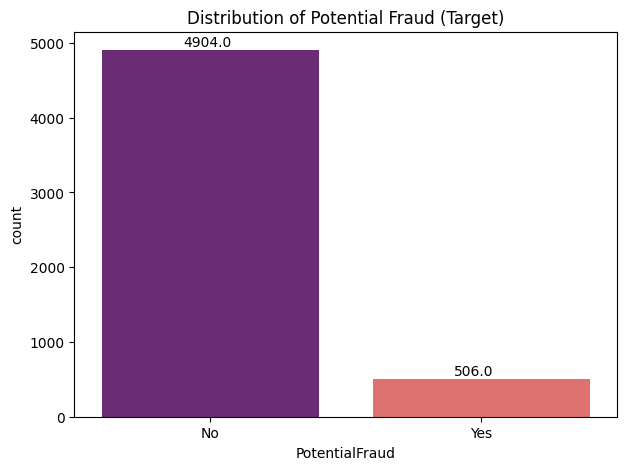

Percentage Distribution:
PotentialFraud
No     90.64695
Yes     9.35305
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='PotentialFraud', data=train_target, palette='magma')
plt.title('Distribution of Potential Fraud (Target)')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x()+0.3, p.get_height()+50))
plt.show()

print("Percentage Distribution:")
print(train_target['PotentialFraud'].value_counts(normalize=True) * 100)

## **Correlation Metrics**
We examine how strongly the aggregated features correlate with the FraudLabel.

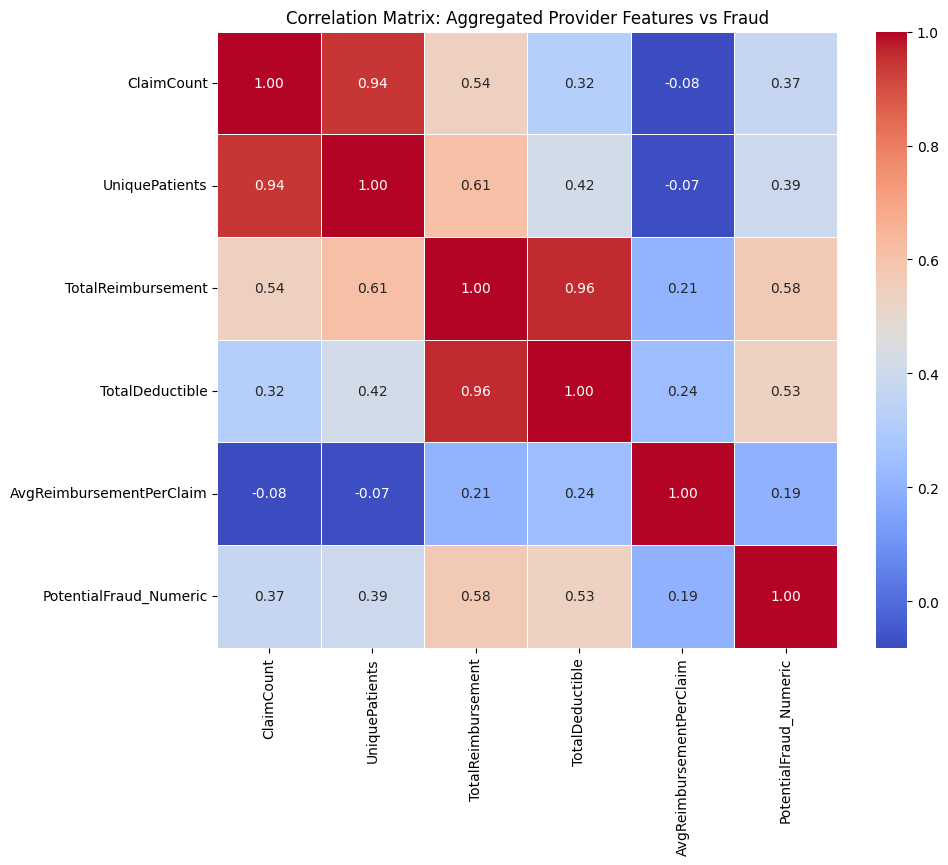

In [ ]:
# Aggregate full_data by Provider to create df_eda
# This step calculates various metrics per provider that can be used as features.
df_agg = full_data.groupby('Provider').agg(
    ClaimCount=('ClaimID', 'nunique'), # Number of unique claims per provider
    UniquePatients=('BeneID', 'nunique'), # Number of unique patients per provider
    TotalReimbursement=('InscClaimAmtReimbursed', 'sum'), # Total reimbursement amount
    TotalDeductible=('DeductibleAmtPaid', 'sum'), # Total deductible paid
    AvgReimbursementPerClaim=('InscClaimAmtReimbursed', 'mean') # Average reimbursement per claim
).reset_index()

# Merge aggregated data with the target labels (PotentialFraud)
df_eda = pd.merge(df_agg, train_target, on='Provider', how='left')

# Convert 'PotentialFraud' to numerical for correlation calculation
df_eda['PotentialFraud_Numeric'] = df_eda['PotentialFraud'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(10, 8))
# Calculating Pearson Correlation
corr_matrix = df_eda.drop(columns=['Provider', 'PotentialFraud']).corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Aggregated Provider Features vs Fraud')
plt.show()

## **Financial Outlier Analysis (Violin Plots)**
Fraudulent providers often exhibit different distribution shapes in their billing amounts.

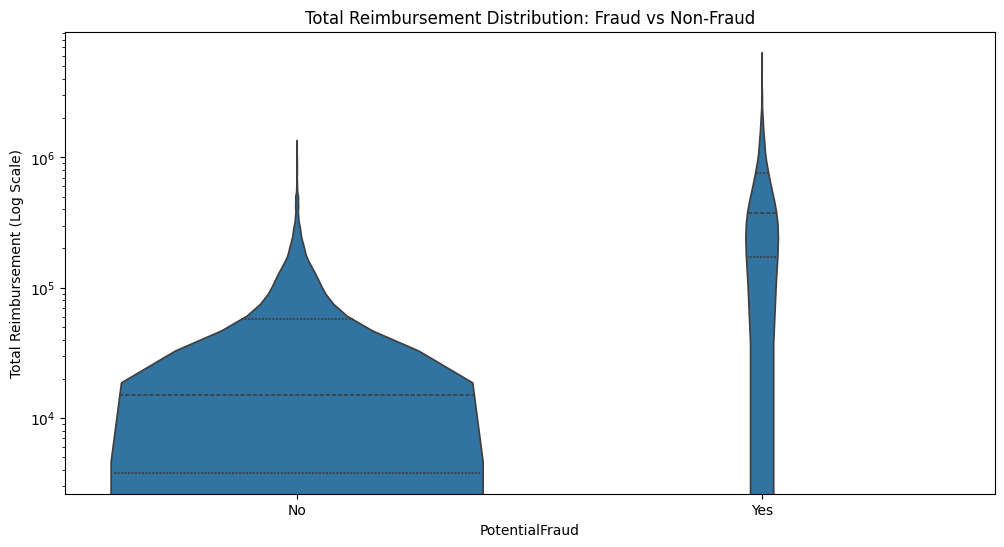

In [ ]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='PotentialFraud', y='TotalReimbursement', data=df_eda, inner="quartile")
plt.yscale('log') # Log scale helps visualize the wide range of billing
plt.title('Total Reimbursement Distribution: Fraud vs Non-Fraud')
plt.ylabel('Total Reimbursement (Log Scale)')
plt.show()

## **Claim Volume vs. Patient Count**
One common fraud indicator is a provider having an unusually high number of claims per patient.

/tmp/ipython-input-960217456.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_eda[df_eda['PotentialFraud']=='No']['ClaimsPerPatient'], label='Not Fraud', shade=True)
/tmp/ipython-input-960217456.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_eda[df_eda['PotentialFraud']=='Yes']['ClaimsPerPatient'], label='Fraud', shade=True)


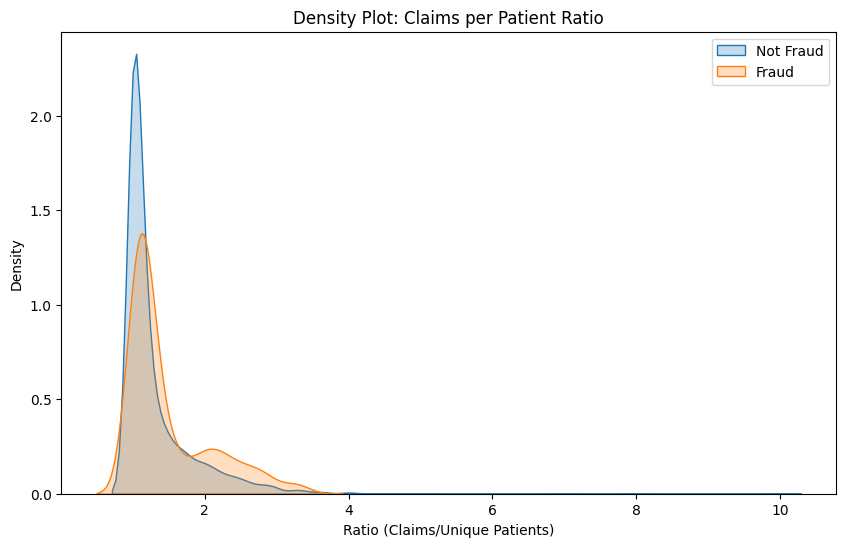

In [ ]:
df_eda['ClaimsPerPatient'] = df_eda['ClaimCount'] / df_eda['UniquePatients']

plt.figure(figsize=(10, 6))
sns.kdeplot(df_eda[df_eda['PotentialFraud']=='No']['ClaimsPerPatient'], label='Not Fraud', shade=True)
sns.kdeplot(df_eda[df_eda['PotentialFraud']=='Yes']['ClaimsPerPatient'], label='Fraud', shade=True)
plt.title('Density Plot: Claims per Patient Ratio')
plt.xlabel('Ratio (Claims/Unique Patients)')
plt.legend()
plt.show()

In [ ]:
full_data.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,Type,PotentialFraud
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inpatient,Yes
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,Inpatient,No
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inpatient,No
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,Inpatient,No
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,Inpatient,No


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Date Conversion & Duration Calculation
date_cols = ['ClaimStartDt', 'ClaimEndDt', 'AdmissionDt', 'DischargeDt']
for col in date_cols:
    if col in full_data.columns:
        full_data[col] = pd.to_datetime(full_data[col])

# Create numeric features from dates (XGBoost can't read raw dates)
full_data['ClaimDuration'] = (full_data['ClaimEndDt'] - full_data['ClaimStartDt']).dt.days
full_data['HospStayDuration'] = (full_data['DischargeDt'] - full_data['AdmissionDt']).dt.days.fillna(0)

# 2. Extract value from Diagnosis/Procedure "Object" codes
# We count how many codes are present per claim
diag_cols = [col for col in full_data.columns if 'Diagnosis' in col]
proc_cols = [col for col in full_data.columns if 'Procedure' in col]

full_data['TotalDiag'] = full_data[diag_cols].notnull().sum(axis=1)
full_data['TotalProc'] = full_data[proc_cols].notnull().sum(axis=1)

# 3. Clean Target & Type
full_data['PotentialFraud'] = full_data['PotentialFraud'].map({'Yes': 1, 'No': 0})
full_data['IsInpatient'] = full_data['Type'].apply(lambda x: 1 if x == 'Inpatient' else 0)

# 4. Drop the "Object" columns that cause errors
# We drop IDs and raw string codes (high cardinality)
cols_to_drop = (date_cols + diag_cols + proc_cols +
                ['BeneID', 'ClaimID', 'Type', 'Provider', 'DiagnosisGroupCode'])

# Auto-detect any remaining object columns to prevent XGBoost crashes
remaining_objs = full_data.drop(columns=['PotentialFraud']).select_dtypes(include=['object']).columns
final_drop = list(set(cols_to_drop) | set(remaining_objs))

df_model = full_data.drop(columns=final_drop).fillna(0)

print(f"Cleaned data shape: {df_model.shape}")
print(df_model.dtypes.value_counts()) # Should show only int, float, or bool

Cleaned data shape: (558211, 8)
int64      6
float64    2
Name: count, dtype: int64


In [ ]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Ensure data is split
X = df_model.drop('PotentialFraud', axis=1)
y = df_model['PotentialFraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# --- 1. XGBoost Training ---
# scale_pos_weight helps the model focus on the minority (fraud) class
ratio = float(np.sum(y == 0)) / np.sum(y == 1)
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=ratio,
    eval_metric='aucpr',
    random_state=42
)
xgb_clf.fit(X_train, y_train)

# --- 2. LightGBM Training ---
# is_unbalance=True automatically weights the classes
lgb_clf = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    is_unbalance=True,
    importance_type='gain',
    random_state=42
)
lgb_clf.fit(X_train, y_train)

# --- 3. Random Forest Training ---
# class_weight='balanced' handles the imbalance during tree construction
rf_clf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_clf.fit(X_train, y_train)

print("All three models have been trained successfully.")

[LightGBM] [Info] Number of positive: 170236, number of negative: 276332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026441 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 253
[LightGBM] [Info] Number of data points in the train set: 446568, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.381210 -> initscore=-0.484417
[LightGBM] [Info] Start training from score -0.484417
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

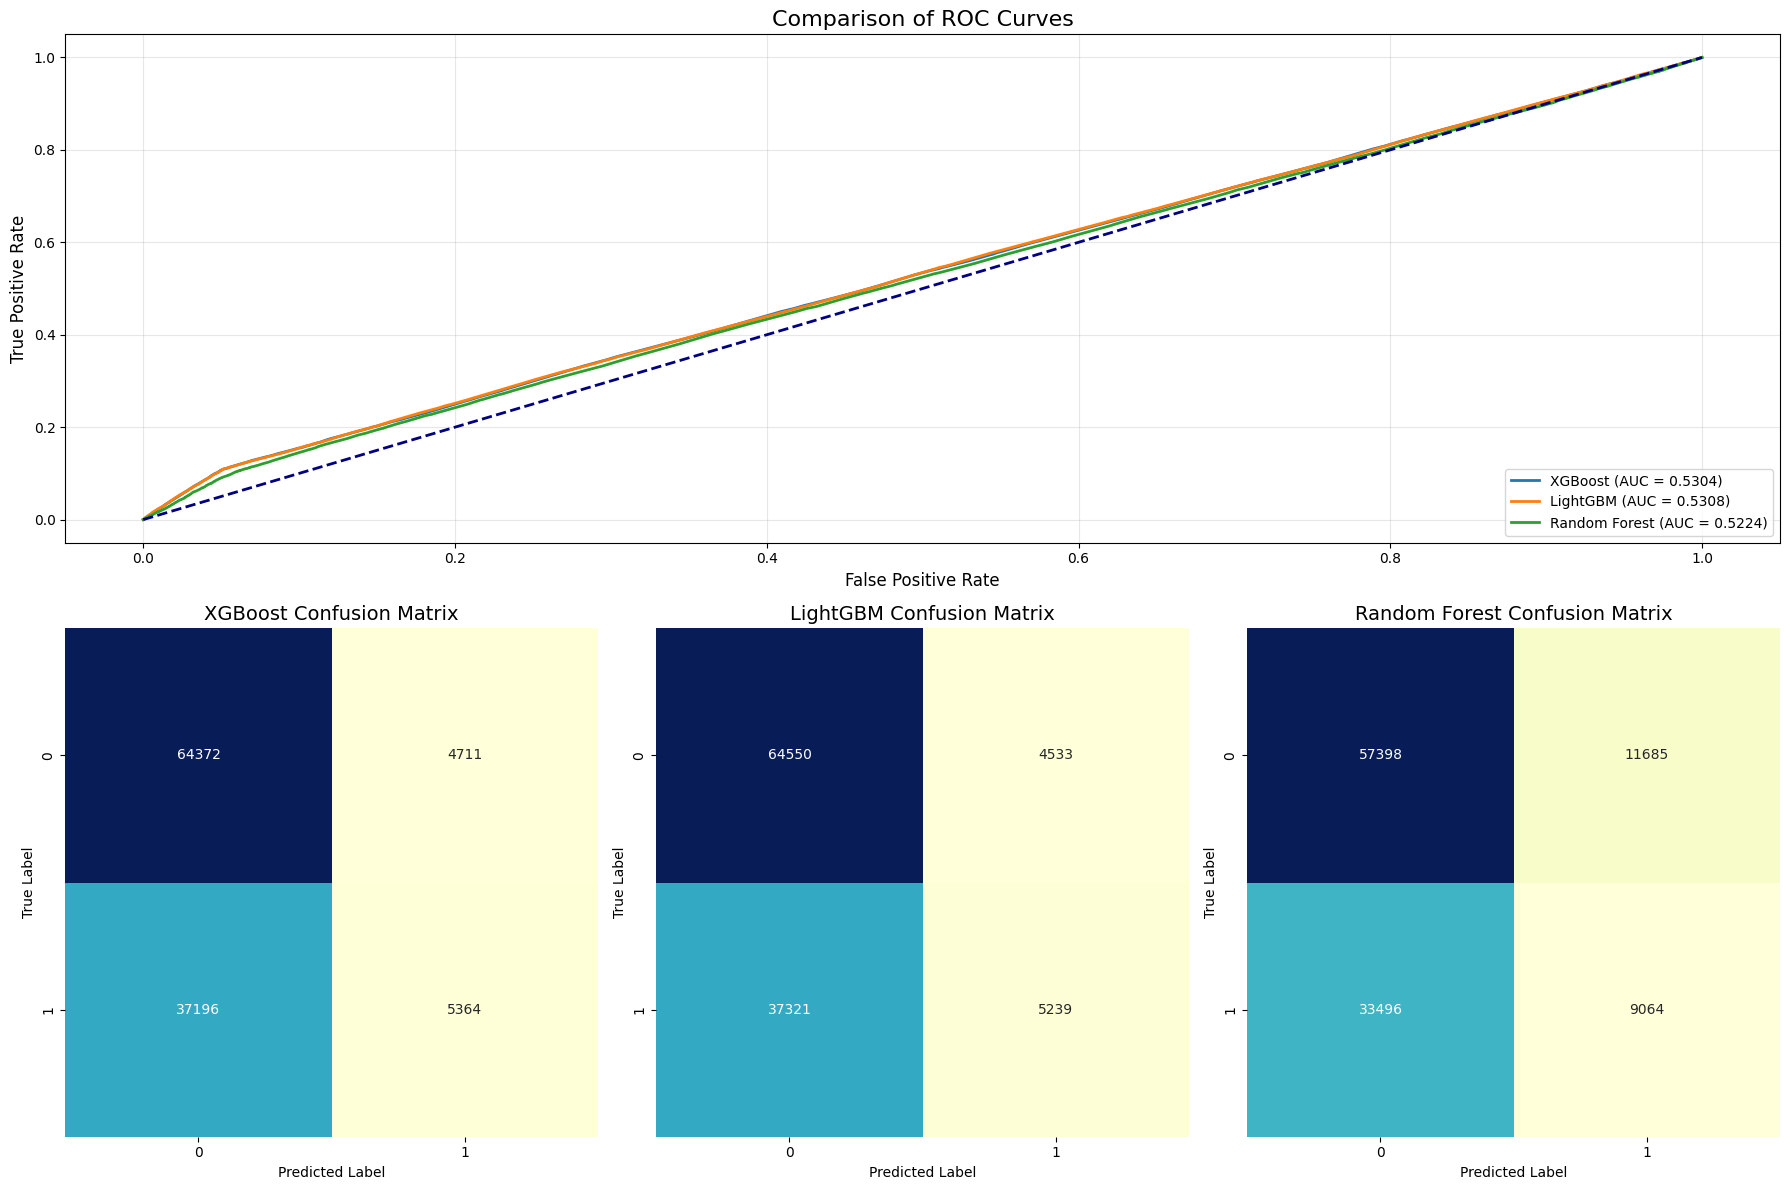

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix

def plot_all_performances(models, X_test, y_test):
    num_models = len(models)
    # Set up a grid: Top row for ROC, bottom row(s) for Confusion Matrices
    fig = plt.figure(figsize=(18, 12))

    # --- 1. Combined ROC Curve (Spanning the top) ---
    ax_roc = plt.subplot2grid((2, num_models), (0, 0), colspan=num_models)
    for name, model in models.items():
        probs = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, probs)
        roc_auc = auc(fpr, tpr)
        ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', lw=2)

    ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax_roc.set_title('Comparison of ROC Curves', fontsize=16)
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.legend(loc='lower right')
    ax_roc.grid(alpha=0.3)

    # --- 2. Individual Confusion Matrices (Bottom Row) ---
    for i, (name, model) in enumerate(models.items()):
        ax_cm = plt.subplot2grid((2, num_models), (1, i))
        preds = model.predict(X_test)
        cm = confusion_matrix(y_test, preds)

        sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=ax_cm, cbar=False)
        ax_cm.set_title(f'{name} Confusion Matrix', fontsize=14)
        ax_cm.set_xlabel('Predicted Label')
        ax_cm.set_ylabel('True Label')

    plt.tight_layout()
    plt.show()

# Execute the updated visualization
models_dict = {'XGBoost': xgb_clf, 'LightGBM': lgb_clf, 'Random Forest': rf_clf}
plot_all_performances(models_dict, X_test, y_test)

In [ ]:
results = []

for name, model in models_dict.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    res = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'AUC-ROC': roc_auc_score(y_test, probs)
    }
    results.append(res)

# Create a Summary Table
perf_df = pd.DataFrame(results).set_index('Model')
print("--- Summarized Evaluation Metrics ---")
print(perf_df.round(4))

# Print Detailed Classification Reports
for name, model in models_dict.items():
    print(f"\nDetailed Classification Report for {name}:")
    print(classification_report(y_test, model.predict(X_test)))

--- Summarized Evaluation Metrics ---
               Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                        
XGBoost          0.6246     0.5324  0.1260    0.2038   0.5304
LightGBM         0.6251     0.5361  0.1231    0.2002   0.5308
Random Forest    0.5953     0.4368  0.2130    0.2863   0.5224

Detailed Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.63      0.93      0.75     69083
           1       0.53      0.13      0.20     42560

    accuracy                           0.62    111643
   macro avg       0.58      0.53      0.48    111643
weighted avg       0.60      0.62      0.54    111643


Detailed Classification Report for LightGBM:
              precision    recall  f1-score   support

           0       0.63      0.93      0.76     69083
           1       0.54      0.12      0.20     42560

    accuracy                           0.63    111643
   macro avg    

Starting Hyperparameter Optimization (Targeting Recall)...
✅ Best parameters for XGBoost: {'scale_pos_weight': np.float64(2.434843393876736), 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
[LightGBM] [Info] Number of positive: 170236, number of negative: 276332
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.033133 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 253
[LightGBM] [Info] Number of data points in the train set: 446568, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.381210 -> initscore=-0.484417
[LightGBM] [Info] Start training from score -0.484417
✅ Best parameters for LightGBM: {'num_leaves': 31, 'n_estimators': 200, 'learning_rate': 0.05, 'is_unbalance': True}
✅ Best parameters for RandomForest: {'n_estimators': 200, 'max_depth': None, 'class_weight': 'balanced'}

FINAL EVALUATION OF OPTIMIZED MODELS
              Accuracy  Precision  Recall (

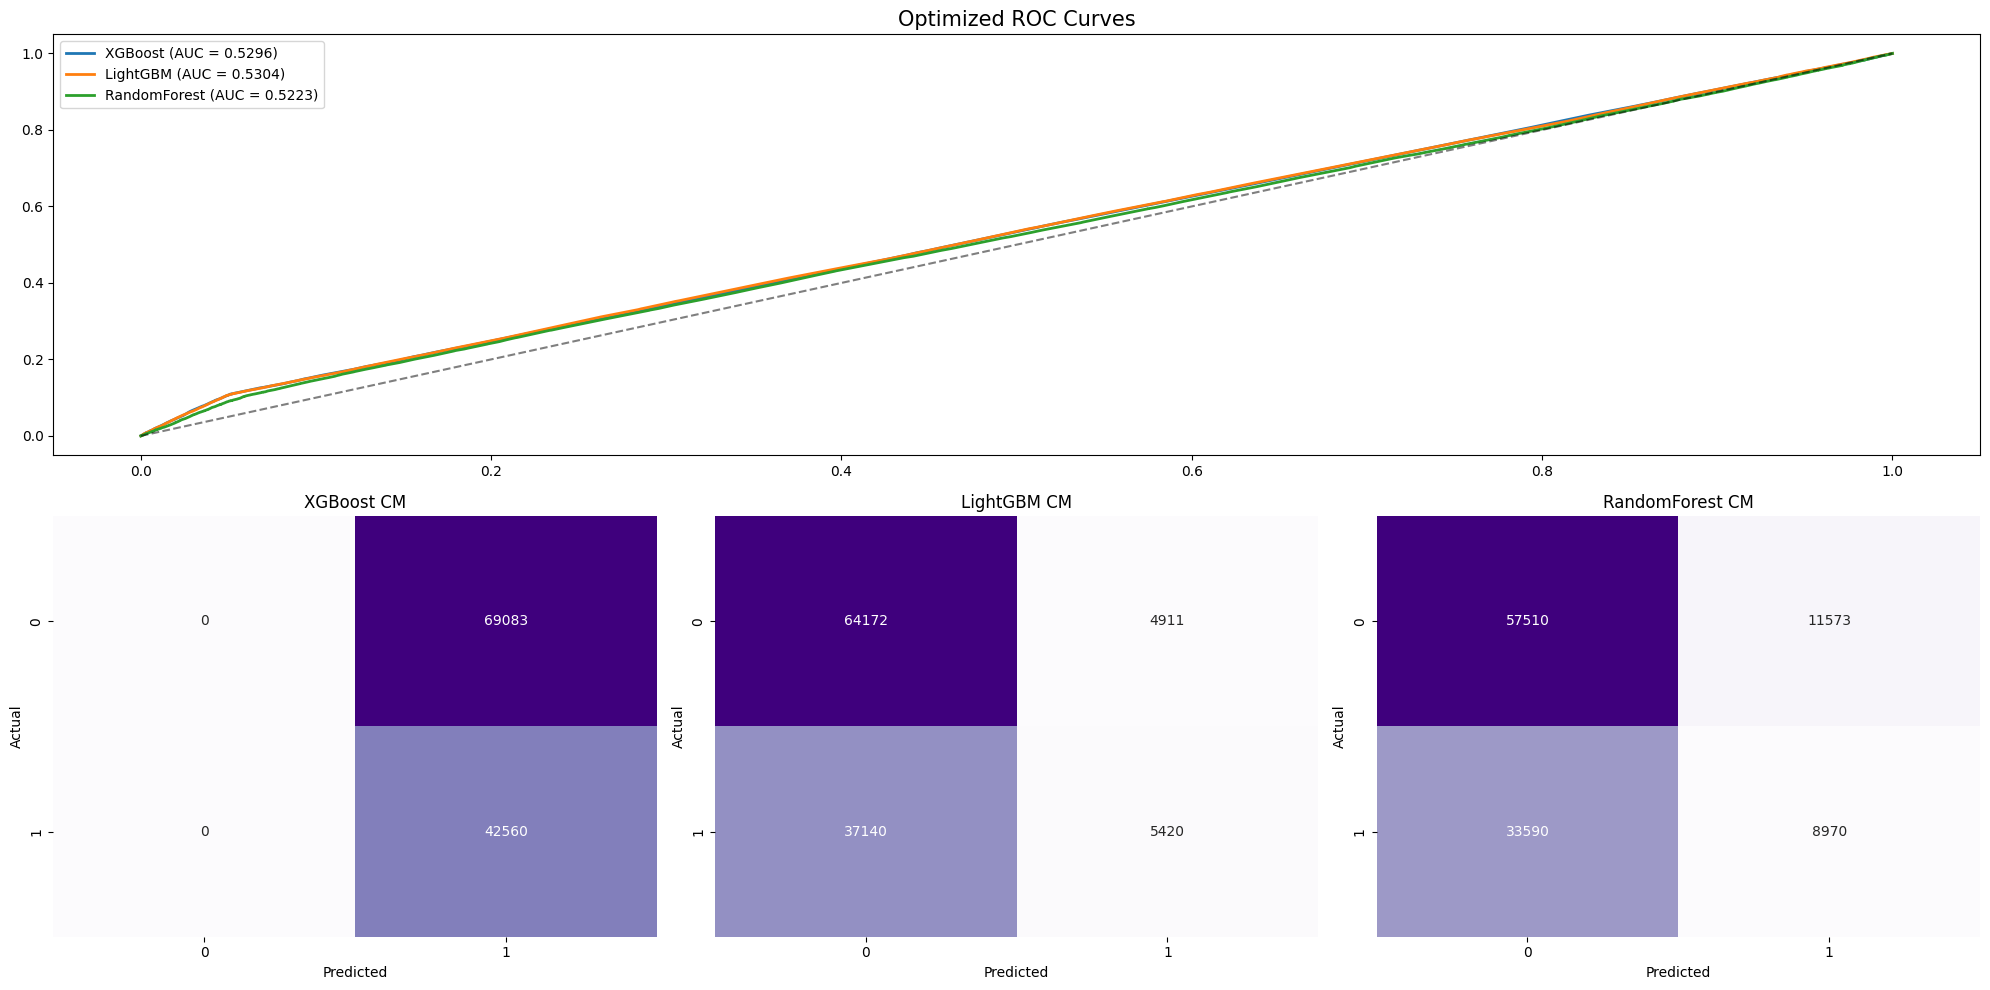

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (roc_curve, auc, confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)

# 1. Setup Search Parameters
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

search_configs = {
    'XGBoost': {
        'model': xgb.XGBClassifier(eval_metric='logloss', random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1],
            'scale_pos_weight': [ratio, ratio * 1.5]
        }
    },
    'LightGBM': {
        'model': lgb.LGBMClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'num_leaves': [31, 64],
            'learning_rate': [0.01, 0.05, 0.1],
            'is_unbalance': [True]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None],
            'class_weight': ['balanced', 'balanced_subsample']
        }
    }
}

optimized_models = {}

# 2. Run Optimization and Print Best Params
print("Starting Hyperparameter Optimization (Targeting Recall)...")
for name, config in search_configs.items():
    search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=5, # Number of iterations per model
        scoring='recall',
        cv=3,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    search.fit(X_train, y_train)
    optimized_models[name] = search.best_estimator_
    print(f"✅ Best parameters for {name}: {search.best_params_}")

# 3. Final Evaluation Summary
summary_data = []
for name, model in optimized_models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    summary_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall (Catch Rate)': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'AUC-ROC': roc_auc_score(y_test, probs)
    })

print("\n" + "="*50)
print("FINAL EVALUATION OF OPTIMIZED MODELS")
print("="*50)
print(pd.DataFrame(summary_data).set_index('Model').round(4))

# 4. Visualization: ROC and Confusion Matrices
fig = plt.figure(figsize=(20, 10))

# ROC Curve
ax_roc = plt.subplot2grid((2, 3), (0, 0), colspan=3)
for name, model in optimized_models.items():
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.4f})', lw=2)

ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax_roc.set_title('Optimized ROC Curves', fontsize=15)
ax_roc.legend()

# Confusion Matrices
for i, (name, model) in enumerate(optimized_models.items()):
    ax_cm = plt.subplot2grid((2, 3), (1, i))
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax_cm, cbar=False)
    ax_cm.set_title(f'{name} CM')
    ax_cm.set_xlabel('Predicted')
    ax_cm.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import RandomizedSearchCV

# 1. Initialize SMOTE
# We'll use a sampling_strategy of 1.0 (making fraud 100% of the size of non-fraud, i.e., balanced)
# to handle the ValueError.
smote = SMOTE(sampling_strategy=1.0, random_state=42)

# 2. Define the Model Dictionary
smote_configs = {
    'XGBoost': {
        'model': xgb.XGBClassifier(eval_metric='logloss', random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [4, 6],
            'classifier__learning_rate': [0.05, 0.1]
        }
    },
    'LightGBM': {
        'model': lgb.LGBMClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__num_leaves': [31, 50],
            'classifier__learning_rate': [0.05, 0.1]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [10, 20]
        }
    }
}

smote_results = {}

print("🚀 Starting SMOTE Balancing and Training...")

for name, config in smote_configs.items():
    # Create the imbalanced-learn pipeline
    pipeline = ImbPipeline([
        ('smote', smote),
        ('classifier', config['model'])
    ])

    # Run Randomized Search
    search = RandomizedSearchCV(
        pipeline,
        config['params'],
        n_iter=5,
        scoring='f1',
        cv=3,
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_train, y_train)
    smote_results[name] = search.best_estimator_
    print(f"✅ {name} optimized with SMOTE.")

# 3. Comprehensive Evaluation
final_metrics = []
for name, model in smote_results.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    final_metrics.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'AUC-ROC': roc_auc_score(y_test, probs)
    })

# Display Results
smote_perf_df = pd.DataFrame(final_metrics).set_index('Model')
print("\n--- FINAL PERFORMANCE WITH SMOTE ---")
print(smote_perf_df.round(4))

🚀 Starting SMOTE Balancing and Training...
✅ XGBoost optimized with SMOTE.
[LightGBM] [Info] Number of positive: 276332, number of negative: 276332
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.044374 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 451
[LightGBM] [Info] Number of data points in the train set: 552664, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
✅ LightGBM optimized with SMOTE.


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


✅ RandomForest optimized with SMOTE.

--- FINAL PERFORMANCE WITH SMOTE ---
              Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                       
XGBoost         0.6152     0.4855  0.1571    0.2374   0.5284
LightGBM        0.6164     0.4897  0.1508    0.2306   0.5279
RandomForest    0.6065     0.4594  0.1820    0.2607   0.5263


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. Initialize Stratified K-Fold
# This ensures each fold has the same ratio of Fraud:Non-Fraud as the original data
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Define your optimized tree models
# (Using the models we defined/optimized in previous steps)
tree_models = {
    'XGBoost': xgb_clf,
    'LightGBM': lgb_clf,
    'Random Forest': rf_clf
}

cv_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_summary = {}

print("🚀 Starting Stratified 5-Fold Cross-Validation...")

for name, model in tree_models.items():
    # Perform cross-validation
    # n_jobs=-1 uses all CPU cores for speed
    scores = cross_validate(model, X, y, cv=skf, scoring=cv_metrics, n_jobs=-1)

    # Calculate means and standard deviations
    cv_summary[name] = {
        'Avg Accuracy': np.mean(scores['test_accuracy']),
        'Avg Precision': np.mean(scores['test_precision']),
        'Avg Recall': np.mean(scores['test_recall']),
        'Avg F1-Score': np.mean(scores['test_f1']),
        'Avg AUC-ROC': np.mean(scores['test_roc_auc']),
        'AUC StdDev': np.std(scores['test_roc_auc'])
    }
    print(f"✅ {name} evaluation complete.")

# 3. Display Comparison Table
results_df = pd.DataFrame(cv_summary).T
print("\n--- STRATIFIED CV RESULTS SUMMARY ---")
print(results_df.round(4))

🚀 Starting Stratified 5-Fold Cross-Validation...
✅ XGBoost evaluation complete.
✅ LightGBM evaluation complete.
✅ Random Forest evaluation complete.

--- STRATIFIED CV RESULTS SUMMARY ---
               Avg Accuracy  Avg Precision  Avg Recall  Avg F1-Score  \
XGBoost              0.6250         0.5341      0.1279        0.2064   
LightGBM             0.6256         0.5381      0.1264        0.2047   
Random Forest        0.5944         0.4354      0.2157        0.2884   

               Avg AUC-ROC  AUC StdDev  
XGBoost             0.5316      0.0016  
LightGBM            0.5317      0.0014  
Random Forest       0.5230      0.0008  


/tmp/ipython-input-1692682361.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


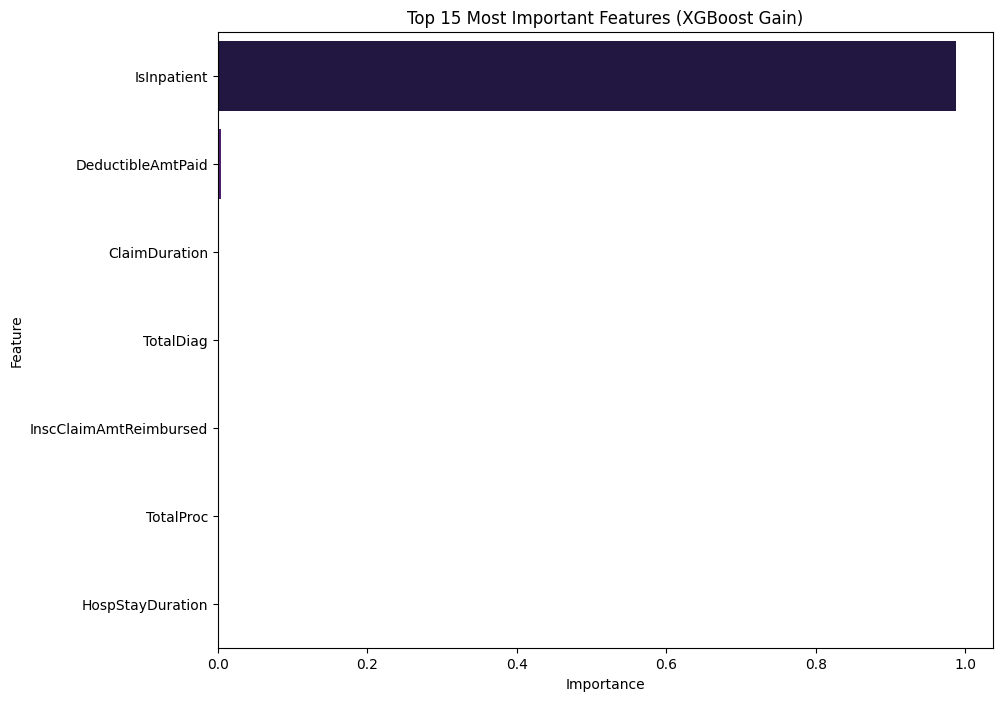

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# We'll use XGBoost as the example, but you can swap in lgb_clf
# Sorting features by importance
importances = xgb_clf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Top 15 Most Important Features (XGBoost Gain)')
plt.show()